In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [2]:
ticker = 'AAPL'
data = yf.download(ticker, start="2020-01-01", end="2025-01-01")
data = data['Close'].values.reshape(-1, 1)

/tmp/ipython-input-3603964004.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [4]:
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data)
X = X.reshape(X.shape[0], X.shape[1], 1)

In [5]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [6]:
model = Sequential()
model.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(SimpleRNN(units=50, return_sequences=False))
model.add(Dense(units=1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.fit(X_train, y_train, epochs=20, batch_size=64)

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0593
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0072
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0029
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0014
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 8.9146e-04
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7.7434e-04
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 7.7126e-04
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 6.0812e-04
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 5.5508e-04
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.4227e-04
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 5.1090e-04
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4.8631e-04
Epoch 13/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 4.6155e-04
Epoch 14/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4.0433e-04
Epoch 15/20
15/15 ━━━━━━━━━━━━━

In [9]:
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

mse = mean_squared_error(y_test_unscaled, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_unscaled, predictions)

print(f"Unscaled Mean Squared Error (MSE): {mse}")
print(f"Unscaled Root Mean Squared Error (RMSE): {rmse}")
print(f"Unscaled Mean Absolute Error (MAE): {mae}")

Unscaled Mean Squared Error (MSE): 56.73047690604678
Unscaled Root Mean Squared Error (RMSE): 7.531963681938913
Unscaled Mean Absolute Error (MAE): 5.969296709696452


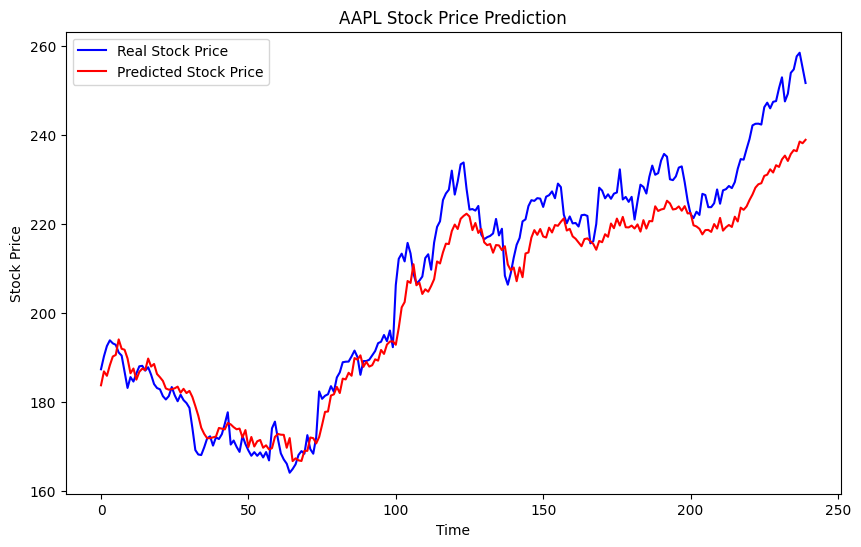

In [10]:
plt.figure(figsize=(10,6))
plt.plot(scaler.inverse_transform(y_test.reshape(-1, 1)), color='blue', label='Real Stock Price')
plt.plot(predictions, color='red', label='Predicted Stock Price')
plt.title(f'{ticker} Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()